## --- Metric Evaluations ---

### 1. Library Import

In [1]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import matplotlib.pyplot as plt
import nltk
nltk.download("wordnet")
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score

C:\Users\Léna\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Léna\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### 2. Embeddings + Cosinus similarity 

In [7]:
# CONFIG
FILE_1 = "data/wiki_original_text.csv"
FILE_2 = "data/reconstructed/wiki_reconstructed_GEMINI_FEWSHOT.csv"
OUTPUT_FILE = "data/similarity_scores_new_prompt.csv"
ID_COLUMN = "id"
TEXT_COLUMN = "text"
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

In [8]:
# load datz
df1 = pd.read_csv(FILE_1)
df2 = pd.read_csv(FILE_2)

# quick verif
if not df1[ID_COLUMN].equals(df2[ID_COLUMN]):
    raise ValueError("Ids problem")

In [9]:
model = SentenceTransformer(MODEL_NAME)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2080.26it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
# GENERATE EMBEDDINGS
texts1 = df1[TEXT_COLUMN].astype(str).tolist()
texts2 = df2[TEXT_COLUMN].astype(str).tolist()

print("embeddings d1")
embeddings1 = model.encode(
    texts1,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True  # mmm idk if i keep this
)

print("Embeddings d2")
embeddings2 = model.encode(
    texts2,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

embeddings d1


Batches: 100%|██████████| 4/4 [00:02<00:00,  1.43it/s]


Embeddings d2


Batches: 100%|██████████| 4/4 [00:02<00:00,  1.46it/s]


In [11]:
# COSINE SIMILARITY line per line
# We normalized the embeddings, so we can just do a dot product
scores = np.sum(embeddings1 * embeddings2, axis=1)

# OUTPUT CSV
result_df = pd.DataFrame({
    ID_COLUMN: df1[ID_COLUMN],
    "original_text": texts1,
    "reconstructed_text": texts2,
    "similarity_score": scores
})

result_df.to_csv(OUTPUT_FILE, index=False)

#### Let's compare the results between the strict rules prompt and the more natural prompt

In [19]:
df_strict = pd.read_csv("data/similarity_scores_old_prompt_cosine_bleu_meteor.csv")
pd.set_option('display.max_colwidth', None)


In [20]:
df_natural = pd.read_csv("data/similarity_scores_new_prompt.csv") 
pd.set_option('display.max_colwidth', None)


In [16]:
df_natural.columns = df_natural.columns.str.strip()
df_strict.columns = df_strict.columns.str.strip()

def compute_stats(df, name):
    return {
        "dataset": name,
        "mean_similarity": df["similarity_score"].mean(),
        "median_similarity": df["similarity_score"].median(),
        "min_similarity": df["similarity_score"].min(),
        "max_similarity": df["similarity_score"].max(),
        "std_similarity": df["similarity_score"].std(),
        "count": len(df)
    }

# calculate stats 
stats_new = compute_stats(df_natural, "df_natural")
stats_old = compute_stats(df_strict, "df_strict")

# to compare
df_stats = pd.DataFrame([stats_new, stats_old])

print("\n===== Statistiques comparatives =====")
print(df_stats)


===== Statistiques comparatives =====
      dataset  mean_similarity  median_similarity  min_similarity  \
0  df_natural         0.326586           0.321297       -0.052848   
1   df_strict         0.314511           0.279989       -0.024009   

   max_similarity  std_similarity  count  
0             1.0        0.198935    100  
1             1.0        0.186581    100  


#### We are going to look at the lowest / highest scores with cosinus similarity 

In [21]:
# For the new prompt, the more natural one
df_sorted_natural = df_natural.sort_values("similarity_score", ascending=False)

df_best_natural = df_sorted_natural.head(5)
df_worst_natural = df_sorted_natural.tail(15).sort_values("similarity_score", ascending=True)  

In [22]:
df_best_natural

,id,original_text,reconstructed_text,similarity_score
95,46516261,It was added to the National Register of Historic Places in 1992.,It was added to the National Register of Historic Places in 1992.,1.000000
39,66287119,"George Plater served as president of the convention, and Wiliam Harwood served as secretary. On April 28, 1788, the convention ratified the Constitution of the United States, in a vote of 63 in favor and 11 opposed. The 63 delegates in favor signed their names to a written copy of the Constitution, making Maryland the only of the first thirteen states to sign their approval in ink.","James Madison served as recorder of the convention, and George Washington served as president. On April 28, 1788, the Convention approved the Constitution of the United States, in a vote of 63 in favor and 11 opposed. The 63 delegates in favor signed their names to a engrossed copy of the Constitution, making Maryland the seventh of the original thirteen states to ratify their agreement in 1788.",0.883557
36,45112113,She was born in Venezuela and moved to the United States when she was 4 months old.,She was born in Australia and moved to the United States when she was 4 months old.,0.799623
17,6850592,"In 1969, then Prime Minister Pierre Trudeau and Minister of Indian Affairs Jean Chrétien released a policy document officially entitled Statement of the Government of Canada on Indian policy. Better known as the White Paper, this policy proposed a dismantling of the Indian Act and an end to the special relationship between Indigenous Peoples and the Canadian Government. Many Indigenous groups across Canada protested this policy change and expressed concern regarding the Canadian Government's failure to incorporate feedback raised during the consultation process. In British Columbia, a generation of emerging Indigenous leaders began to organize in response. Rose Charlie of the Indian Homemakers' Association, Philip Paul of the Southern Vancouver Island Tribal Federation and Don Moses of the North American Indian Brotherhood invited bands from across the province to a conference in Kamloops to discuss the policy and the recognition of Aboriginal title and rights more generally. The conference was a success with over 140 bands represented and it resulted in the formation of the Union of British Columbia Indian Chiefs, an organization dedicated to the resolution of land claims.","In 1969, four Native American Richard Oakes and members of Indians of All Tribes launched a major protest action focused on Declaration of the occupation of Indian on federal lands. Rather known as the White Paper, this action outlined a termination of the Indian Act and an end to the paternalistic relationship between Indigenous peoples and the Federal government. Many Indigenous tribes across Canada supported this protest action and organized rallies opposing the Federal government's failure to recognize land claims denied during the assimilation period. In Western Canada, a generation of emerging Indigenous leaders rose to prominence in politics. Many leaders of the United Native Nations' organization, George Manuel of the National Indian Brotherhood and Art Manual of the National Indian Youth Council called chiefs from across the country to a conference in Edmonton to discuss the action and the importance of Indigenous rights and lands with government. The conference was a success with over 140 chiefs participating and it resulted in the formation of the Union of British Columbia Indian Chiefs, an organization dedicated to the protection of band lands.",0.789738
29,13463379,"In 1928 he was the helmsman of the Estonian boat Tutti V which won the bronze medal in the 6 metre class; the crew also included William von Wirén, Georg Faehlmann, Andreas Faehlmann and Eberhard Vogdt. It was the only event in the history of the Olympics when five Estonian sportspeople won medals.","In 1928 he was the helmsman of the German boat Class R which won the silver medal in the

In [23]:
df_worst_natural

,id,original_text,reconstructed_text,similarity_score
51,28382036,"Kulina is a village in Vinni Parish, Lääne-Viru County, in northeastern Estonia.","Before the emergence of transformer-based models in 2017, some language models were considered large relative to the computational and data constraints of their time. \nIn the early 1990s, IBM's statistical models pioneered word alignment techniques for machine translation, laying the groundwork for corpus-based language modeling.",-0.052848
40,36108762,"Hobart was the son of Miles Hobart of London & Harleyford (though others have confused him with the son of Sir Henry Hobart, 1st Baronet). He matriculated at Queen's College, Oxford on 30 June 1615, aged 16 and was a student of Gray's Inn in 1616. He was knighted at Salisbury on 8 August 1623. In 1628, he was elected Member of Parliament for Marlow. In the debate of 2 March 1629 about the ""illegal imposition of Tonnage and Poundage"" he locked the door of the House of Commons, against the King's Messenger and was accordingly imprisoned in the Tower of London. He sat until 1629, when King Charles I of England decided to rule without Parliament for eleven years.","Before the emergence of transformer-based models in 2017, some language models were considered large relative to the computational and data constraints of their time. \nIn the early 1990s, IBM's statistical models pioneered word alignment techniques for machine translation, laying the groundwork for corpus-based language modeling.",-0.018269
93,70696809,"Knudsen was born in Badger, Kingsbury County, South Dakota. He grew up in Kandiyohi, Kandiyohi County, Minnesota and lived with his wife and family on a farm in Kandiyohi, Minnesota. He went to public school in Kandiyohi, Minnesota. Knudsen was a farmer and raised cattle. He served on the Kandiyohi School Board from 1946 to 1954 and was the chair of the school board. Knudsen served in the Minnesota House of Representatives from 1955 to 1962 and in the Minnesota Senate from 1963 to 1966. In 1979, he moved to Spicer, Minnesota. Knudsen died from a heart attack in Kandiyohi, Minnesota while doing carpentry work.","Before the emergence of transformer-based models in 2017, some language models were considered large relative to the computational and data constraints of their time. \nIn the early 1990s, IBM's statistical models pioneered word alignment techniques for machine translation, laying the groundwork for corpus-based language modeling.",-0.000587
59,53500744,"Ixa is a genus of Indo-Pacific pebble crabs from the family Leucosiidae. The genus was erected by William Elford Leach in 1816. One species, the Red Sea pebble crab (Ixa monodi), is a Lessepsian migrant and the species was first described to science from specimens collected on the Mediterranean Sea although the species is native to the Red Sea and had colonised the eastern Mediterranean through the Suez Canal.","Rum is a spirit of West-Indian origin made from the sugar Caribbean. The spirit was created by Charles Lewis King in 1816. The village, the Rio Bay battle site (The Battle), is a Jamaican victory and the Spanish was later despatched to recover from Englishmen occupants on the Caribbean Sea although the battle is native to the Rio Nuevo and had extended the entire Caribbean through the West Indies.",0.006677
31,26075746,Galagammulla is a small town in Sri Lanka. It is located within Southern Province.,Williamsburg is a large area in New York. It is listed within Historic District.,0.007832
24,23660823,"Ulochora is a monotypic moth genus in the family Cosmopterigidae described by Edward Meyrick in 1920. It contains only one species, Ulochora streptosema, described by the same author in the same year, which is found in Fiji.","The phrase is a literary term coined in the post-World-War-I disillusionment popularized by Ernest Hemingway in 1920. It consists of the writers, American expatriates, who gathered in the Left Bank cafés in the Latin Quarter, which is l

In [24]:
# For the old prompt, the strict one
df_sorted_strict = df_strict.sort_values("similarity_score", ascending=False)

df_best_strict = df_sorted_strict.head(5)
df_worst_strict = df_sorted_strict.tail(5).sort_values("similarity_score", ascending=True)  

In [25]:
df_best_strict

,id,original_text,reconstructed_text,similarity_score,bleu_score,meteor_score
95,46516261,It was added to the National Register of Historic Places in 1992.,It was added to the National Register of Historic Places in 1992.,1.000000,1.000000,0.999711
39,66287119,"George Plater served as president of the convention, and Wiliam Harwood served as secretary. On April 28, 1788, the convention ratified the Constitution of the United States, in a vote of 63 in favor and 11 opposed. The 63 delegates in favor signed their names to a written copy of the Constitution, making Maryland the only of the first thirteen states to sign their approval in ink.","Robert Morris served as president of the convention, and William Jackson served as secretary. On December 28, 1787, the convention ratified the Constitution of the United States, in a vote of 63 in favor and 11 opposed. The 63 delegates in favor affixed their names to a written copy of the Constitution, making Delaware the first of the thirteen states",0.769930,0.622012,0.768048
41,25153634,"It is found on hillsides around Kalgoorlie and Coolgardie, and south to about Widgiemooltha in the Goldfields region of Western Australia where it grows in stony loam or clay and red sandy soils.","It is found on riverbanks around Queensland and Victoria, and spreads to cover New South Wales in the Eastern region of South Australia where it grows in sandy soil or clay and forms dense mats.",0.705969,0.239838,0.621235
54,200730,"Robert Crosbie House, 62 Queen's Gardens, LONDON W2 3AH, ENGLAND (London, England)","Robert William Smith, 62 King's Gardens, London W2 3AH, England (London, Kingdom)",0.697409,0.047406,0.649089
36,45112113,She was born in Venezuela and moved to the United States when she was 4 months old.,She was born in Australia and sailed to the Western States when she was 4 months old.,0.646667,0.541193,0.813926


In [26]:
df_worst_strict

id  \
14  27014228   
50   7932291   
48  13758555   
26   6840106   
4   37897173   

                                                                                                                                                                                                                                                         original_text  \
14  Gachie is a locality in Kihara ward, Kiambaa constituency, Kiambu county. It is located in Kenya's Kiambu County approximately  from the Nairobi CBD. It neighbors the affluent Nyari Estate. Gachie is named after one of its first settlers and a son of Kihara.   
50                                                       H.M. Stanley Hospital () was a community hospital in St Asaph, Wales. It was managed by the Betsi Cadwaladr University Health Board. It served as the headquarters of the Welsh Ambulance Service until 2019.   
48                                                                                          Hawthorne Books is an independent publisher founded in 2001 in Portland, Oregon, U.S., specializing in literary fiction and creative nonfiction original trade paperbacks.   
26                                                                                                                                                          Rathdowney GAA is a Gaelic Athletic Association gaelic football club in Rathdowney, County Laois, Ireland.   
4                                                                                                                                                                                      Scopula inactuosa is a moth of the  family Geometridae. It is found on Sumbawa.   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

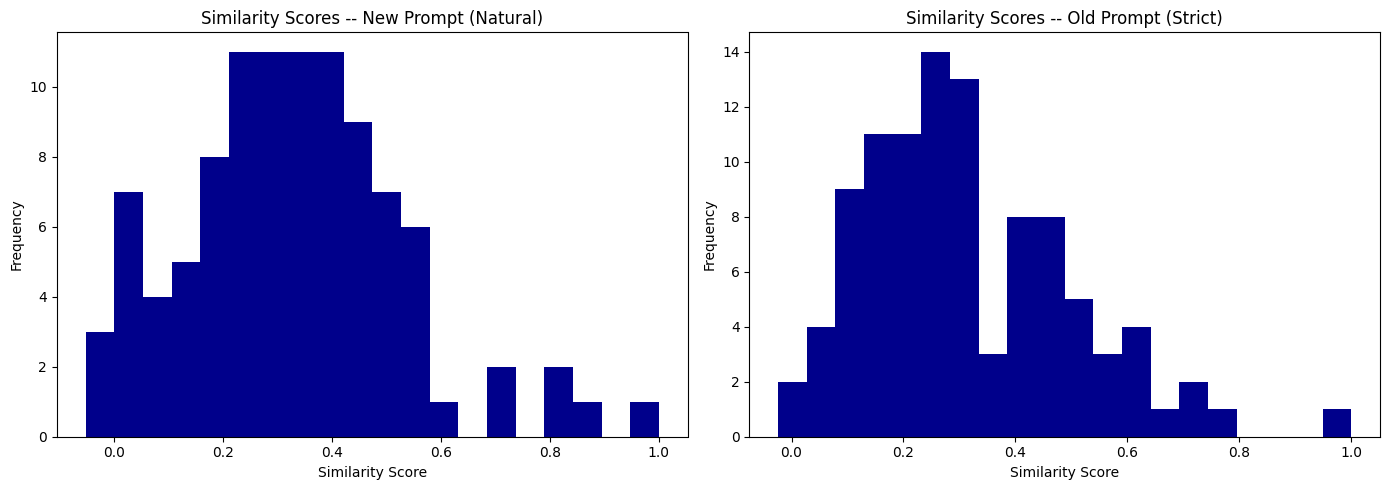

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# fig histogram of similarity scores for the new prompt, the more natural one
axes[0].hist(df_natural["similarity_score"], bins=20, color="darkblue")
axes[0].set_title("Similarity Scores -- New Prompt (Natural)")
axes[0].set_xlabel("Similarity Score")
axes[0].set_ylabel("Frequency")

# fig histogram of similarity scores for the old prompt, the strict one
axes[1].hist(df_strict["similarity_score"], bins=20, color="darkblue")
axes[1].set_title("Similarity Scores -- Old Prompt (Strict)")
axes[1].set_xlabel("Similarity Score")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 3. BLEU score

In [28]:
df_natural.columns = df_natural.columns.str.strip()
df_strict.columns = df_strict.columns.str.strip()

In [29]:
# Bleu function
smooth = SmoothingFunction().method1

def compute_bleu(reference, hypothesis):
    reference_tokens = str(reference).split()
    hypothesis_tokens = str(hypothesis).split()
    
    return sentence_bleu(
        [reference_tokens],
        hypothesis_tokens,
        smoothing_function=smooth
    )

In [ ]:
# Add BLEU column
df_natural["bleu_score"] = df_natural.apply(
    lambda row: compute_bleu(row["original_text"], row["reconstructed_text"]),
    axis=1
)

df_strict["bleu_score"] = df_strict.apply(
    lambda row: compute_bleu(row["original_text"], row["reconstructed_text"]),
    axis=1
)

In [31]:
# Save new files
df_natural.to_csv("similarity_scores_with_bleu.csv", index=False)
# df_strict.to_csv("similarity_scores_old_prompt_with_bleu.csv", index=False)

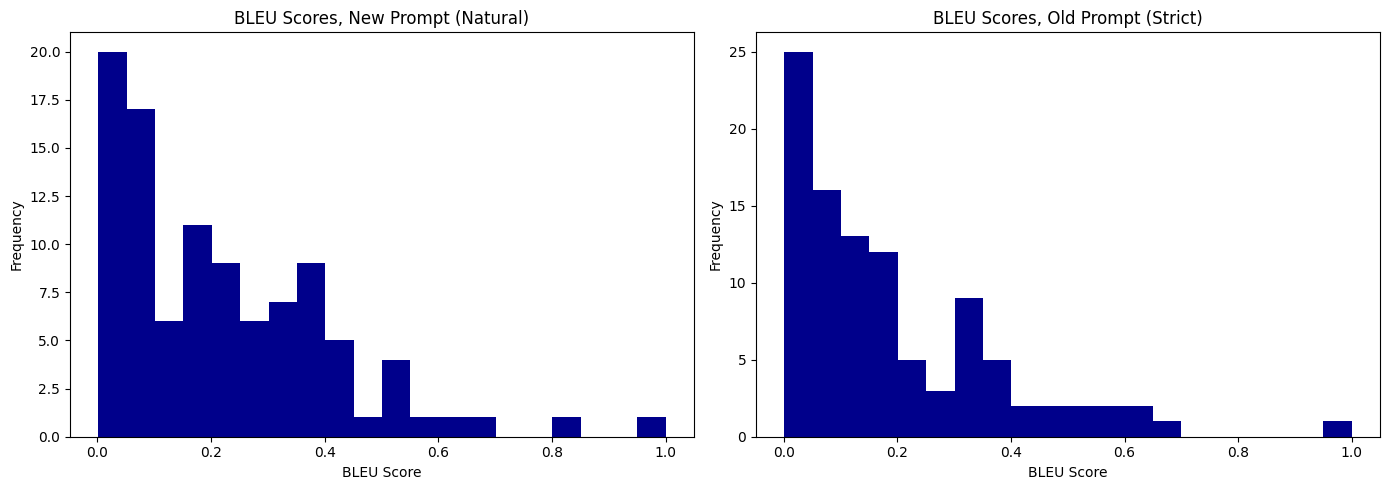

In [32]:
# Histogram of BLEU scores for both datasets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# fig histogram of BLEU scores for the new prompt, the more natural one
axes[0].hist(df_natural["bleu_score"], bins=20, color="darkblue")
axes[0].set_title("BLEU Scores, New Prompt (Natural)")
axes[0].set_xlabel("BLEU Score")
axes[0].set_ylabel("Frequency")

# Fig histogram of BLEU scores for the old prompt, the strict one
axes[1].hist(df_strict["bleu_score"], bins=20, color="darkblue")
axes[1].set_title("BLEU Scores, Old Prompt (Strict)")
axes[1].set_xlabel("BLEU Score")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 4. METEOR Score

In [33]:
# Load csvs with BLEU scores
df_natural_bleu = pd.read_csv("similarity_scores_with_bleu.csv")
# df_strict_bleu = pd.read_csv("similarity_scores_old_prompt_with_bleu.csv")

df_natural_bleu.columns = df_natural_bleu.columns.str.strip()
#df_strict_bleu.columns = df_strict_bleu.columns.str.strip()

In [ ]:
# ==========================
# METEOR FUNCTION
# ==========================
def compute_meteor(reference, hypothesis):
    reference_tokens = str(reference).split()
    hypothesis_tokens = str(hypothesis).split()
    
    return meteor_score(
        [reference_tokens],
        hypothesis_tokens
    )

# Add meteor column
df_natural["meteor_score"] = df_natural.apply(
    lambda row: compute_meteor(row["original_text"], row["reconstructed_text"]),
    axis=1
)

df_strict["meteor_score"] = df_strict.apply(
    lambda row: compute_meteor(row["original_text"], row["reconstructed_text"]),
    axis=1
)


In [35]:
# Save the results
df_natural.to_csv("similarity_scores_with_bleu_meteor.csv", index=False)
# df_strict.to_csv("similarity_scores_old_prompt_with_bleu_meteor.csv", index=False)

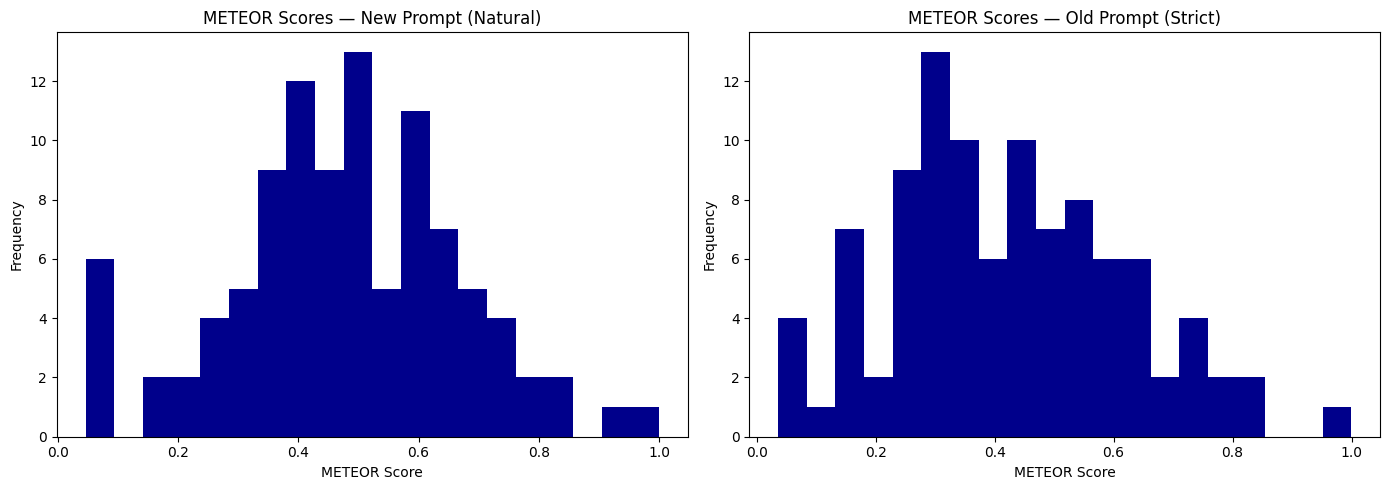

In [36]:
# Histogram of METEOR scores for both datasets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# fig histogram of METEOR scores for the new prompt, the more natural one
axes[0].hist(df_natural["meteor_score"], bins=20, color="darkblue")
axes[0].set_title("METEOR Scores — New Prompt (Natural)")
axes[0].set_xlabel("METEOR Score")
axes[0].set_ylabel("Frequency")

# Fig histogram of METEOR scores for the old prompt, the strict one
axes[1].hist(df_strict["meteor_score"], bins=20, color="darkblue")
axes[1].set_title("METEOR Scores — Old Prompt (Strict)")
axes[1].set_xlabel("METEOR Score")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 5. Correlation Matrix

In [42]:
# We do a correlation matrix to see how the metrics correlate with each other
df_stat = pd.read_csv("similarity_scores_with_bleu_meteor.csv")

df_stat.columns = df_stat.columns.str.strip()
metrics = df_stat[["similarity_score", "bleu_score", "meteor_score"]]
correlation_matrix = metrics.corr(method="pearson")
correlation_matrix

,similarity_score,bleu_score,meteor_score
similarity_score,1.000000,0.606615,0.616643
bleu_score,0.606615,1.000000,0.897472
meteor_score,0.616643,0.897472,1.000000


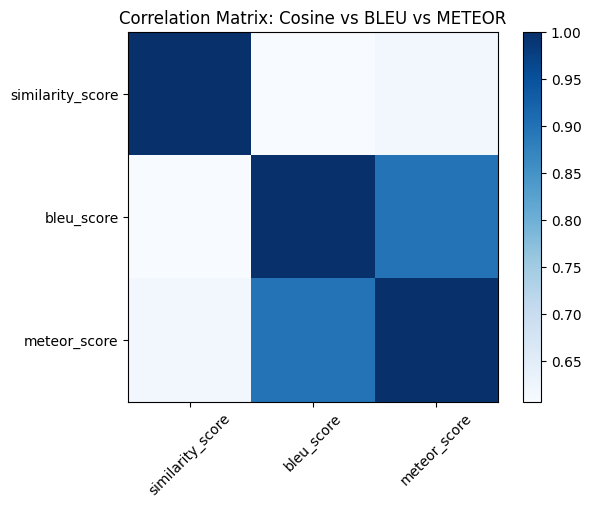

In [43]:
# Some visualization of the correlation matrix
plt.figure()
plt.imshow(correlation_matrix, cmap="Blues")
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title("Correlation Matrix: Cosine vs BLEU vs METEOR")
plt.show()

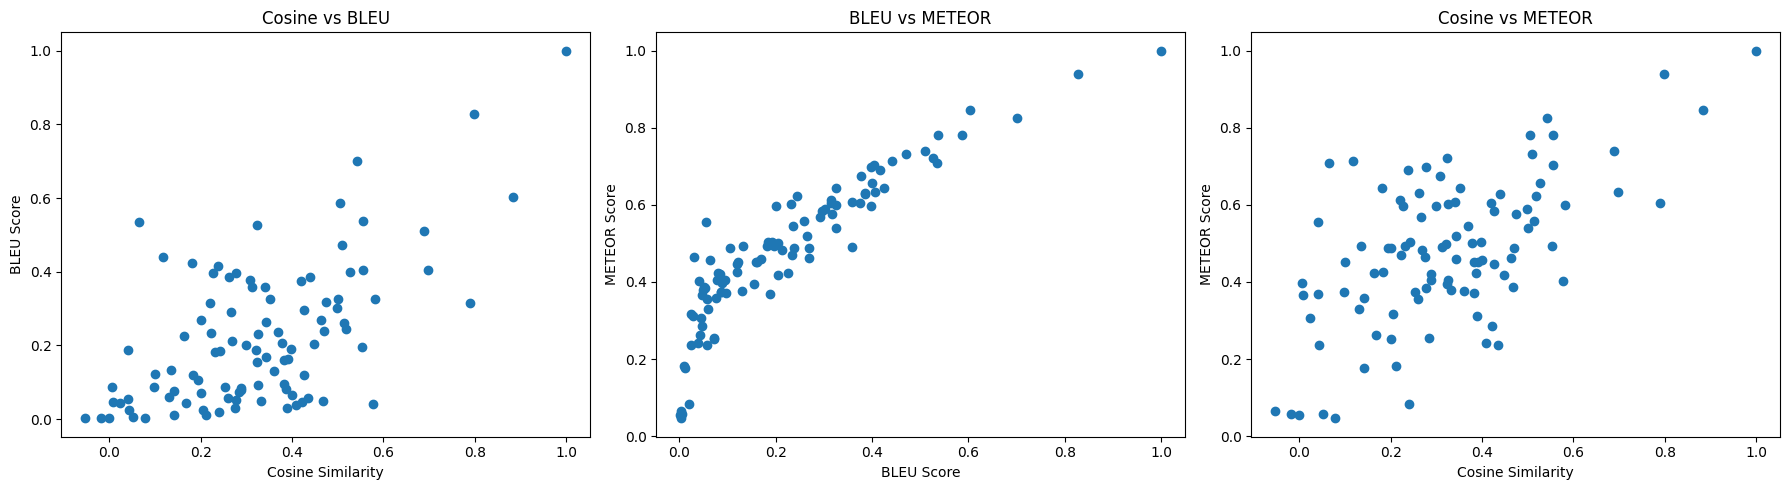

In [44]:
# Scatter plot of all the metrics to see the correlation between them

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Fig cosine vs bleu
axes[0].scatter(df_stat["similarity_score"], df_stat["bleu_score"])
axes[0].set_xlabel("Cosine Similarity")
axes[0].set_ylabel("BLEU Score")
axes[0].set_title("Cosine vs BLEU")

#Fig bleu vs meteor
axes[1].scatter(df_stat["bleu_score"], df_stat["meteor_score"])
axes[1].set_xlabel("BLEU Score")
axes[1].set_ylabel("METEOR Score")
axes[1].set_title("BLEU vs METEOR")

# Fig cosine vs meteor
axes[2].scatter(df_stat["similarity_score"], df_stat["meteor_score"])
axes[2].set_xlabel("Cosine Similarity")
axes[2].set_ylabel("METEOR Score")
axes[2].set_title("Cosine vs METEOR")

plt.tight_layout()
plt.show()

In [49]:
df_mean = pd.read_csv("data/scores_new_prompt_cosine_bleu_meteor.csv")
scores = ["similarity_score", "bleu_score", "meteor_score"]

# Compute statistics
stats = pd.DataFrame({
    "mean": df_mean[scores].mean(),
    "median": df_mean[scores].median(),
    "std": df_mean[scores].std(),
    "min": df_mean[scores].min(),
    "max": df_mean[scores].max()
})

print("Statistics for Similarity, BLEU and METEOR scores:")
print(stats)

Statistics for Similarity, BLEU and METEOR scores:
                      mean    median       std       min       max
similarity_score  0.326586  0.321297  0.198935 -0.052848  1.000000
bleu_score        0.222219  0.188307  0.192171  0.001917  1.000000
meteor_score      0.478875  0.485989  0.191676  0.046189  0.999711


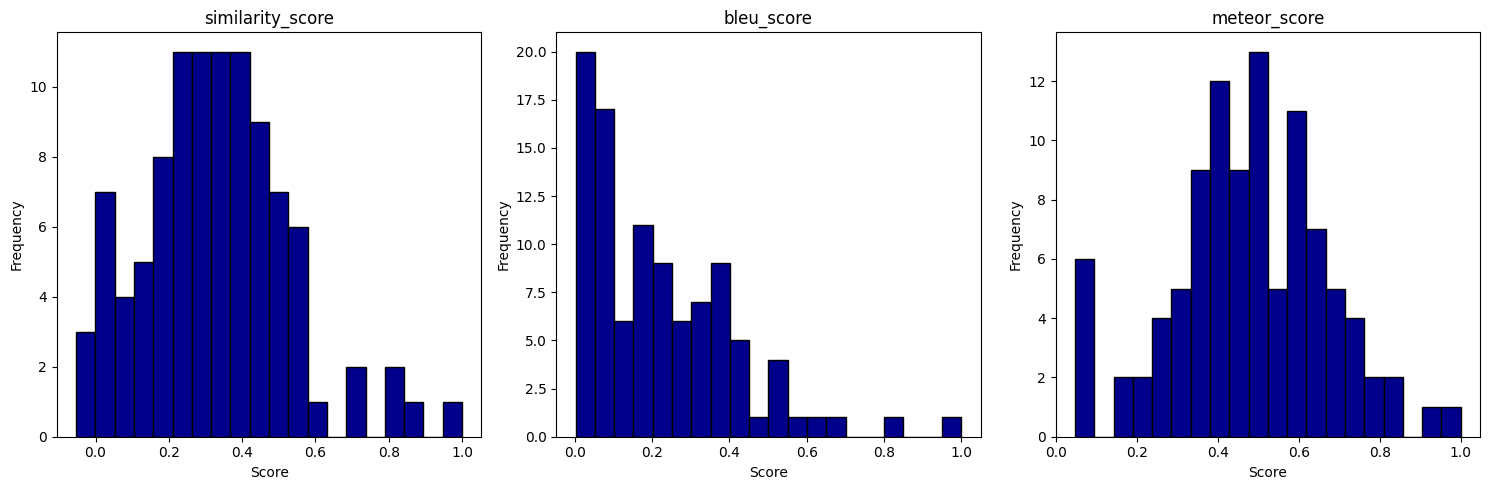

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

# Plot histograms
for ax, score in zip(axes, scores):
    ax.hist(df_mean[score], bins=20, color="darkblue", edgecolor="black")
    ax.set_title(score)
    ax.set_xlabel("Score")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [45]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)


df_stat


,id,original_text,reconstructed_text,similarity_score,bleu_score,meteor_score
0,34335512,"Yuknoom Chʼeen II (September 11, 600 – 680s), known as Yuknoom the Great, was a Maya ruler of the Kaan kingdom, which had its capital at Calakmul during the Classic Period of Mesoamerican chronology.","Heraclius Constans II (September 11, 600 – 680s), known as Konstas the Bearded, was a Roman emperor of the Roman Empire, which had its capital at Syracuse during the Heraclian Dynasty of Thessalonica's fortunes.",0.341344,0.359167,0.606209
1,43869726,Rats and Cats is a 2007 Australian comedy film directed by Tony Rogers and starring Adam Zwar and Jason Gann.,"Lions for Lambs is a 2007 American political drama film directed by Robert Redford and starring Robert Redford, Meryl Streep and Tom Cruise.",0.386186,0.080670,0.423889
2,52082793,Corinne Lagache (born 9 December 1975 in Caen) is a French footballer who played as a goalkeeper for the France women's national football team. She was part of the team at the UEFA Women's Euro 2001. On club level she played for La Roche ESOF in France.,Steffi Jones (born 9 December 1975 in Bonn) is a German defender who played as a defender for the German women's national football team. She was part of the team at the UEFA Women's Euro 2001. On her return she played for SC Bad Neuenahr in Germany.,0.322308,0.526014,0.720248
3,8273434,"World Cup For the World cup 1995 only teams from EURO 1994 qualified so again team Macedonian did not get a chance to participate. At the World Cup's they entered 8 times – 1999, 2009, 2013, 2015, 2017, 2019, 2021 and 2023. The most successful was in 2015 when they finished 9th.","Power Pop For the debut set 1995 album sales from Late 1994 plummeted so badly that Polygram did not get a chance to recuperate. At the Power Pop's they released 8 albums – 1999, 2009, 2013, 2015, 2017, 2019, 2021 and 2023. The best performance was in 2015 when they finished 9th.",0.180006,0.424578,0.642775
4,37897173,Scopula inactuosa is a moth of the family Geometridae. It is found on Sumbawa.,English literature is a form of the global literature. It is based on England.,0.039867,0.054374,0.556362
5,28985107,"The site is to the northeast of the village of Middle Winterslow, and falls mostly within the county of Hampshire, and partly within the county of Wiltshire.","The peak is to the northwest of the western section of Mount Washington, and lies mainly within the county of Merrimack, and partly within the county of Strafford.",0.351589,0.325909,0.644675
6,29512629,"The Gruvleflesa Knolls () are two low rock knolls rising above the Antarctic glacial moraine west of the Gruvletindane Crags, in the Kurze Mountains of Queen Maud Land. They were mapped from surveys and air photos by the Sixth Norwegian Antarctic Expedition (1956–60) and named Gruvleflesa.","The Southernmost Ranges () are the only high ranges rising above the Antarctic exposed bedrock mass of the Transantarctic Range, in the Queen Elizabeth Land of West Antarctica.\nThey were named from surveys and air photos by the United States Geological Survey (1956–60) and called Transantarctic.",0.369743,0.236489,0.546043
7,65425941,"In 1906 he was finally able to abandon tailoring work, becoming instead a salaried party official, working in nearby Hildesheim and Alfeld. Two years later, in 1908, he was elected to membership of the Delligsen municipal council. He was by now gaining a reputation in the region as an effective political orator (or ""agitator""). He took a leading role in Labour movement demonstrations, campaigning powerfully for democratic state elections, which meant campaigning against the infamous ""Dreiklassenwahlrecht"" (literally ""Three-class voting entitlement""), whereby the 80% of voters paying the lowest amounts in tax had the same levels of influence in election results as the richest 5% paying the highest amounts. (The precise proportions varied slightly over time according to tax rates and levels of prosperity, but the u